GraphSAGE

In [1]:
# Cài đặt (hoặc cập nhật) PyTorch Geometric
!pip install --upgrade torch_geometric

# Cài đặt các thư viện phụ trợ (torch-sparse, pyg-lib, v.v.)
# Lệnh này sẽ tự động tìm phiên bản PyTorch và CUDA của bạn để cài đặt các gói tương thích
!pip install torch-scatter torch-sparse torch-cluster pyg-lib -f https://data.pyg.org/whl/torch-$(python -c 'import torch; print(torch.__version__)').html

Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html


Starting Step 1: Load and Prepare Full Graph Data...
Data loaded. Total nodes: 203769

Starting Step 2: Feature Scaling and Mask Creation...
Train nodes: 29894, Val nodes: 7829, Test nodes: 8841

Starting Step 3: Create PyG Data Object...
Using device: cuda
Calculated class weights: tensor([0.5655, 4.3174], device='cuda:0')

Starting Step 4: Create Inductive DataLoaders...

Starting Step 5: Define GraphSAGE Model...

Starting Step 6: Training GraphSAGE Model...
Epoch 005, Train Loss: 0.4002, Val Loss: 2.2755
Epoch 010, Train Loss: 0.2010, Val Loss: 2.4615
Early stopping at epoch 11!
Training complete. Loading best model...

Starting Step 7: Final Evaluation (Overall)...
--- PERFORMANCE REPORT (BASELINE: GraphSAGE) ---

Metrics for 'Illicit' (Class 1):
  Precision: 0.1334
  Recall:    0.5858
  F1-Score:  0.2173

Overall Metrics:
  ROC AUC:   0.8214

Detailed Classification Report:
              precision    recall  f1-score   support

   Licit (0)       0.98      0.82      0.89      843

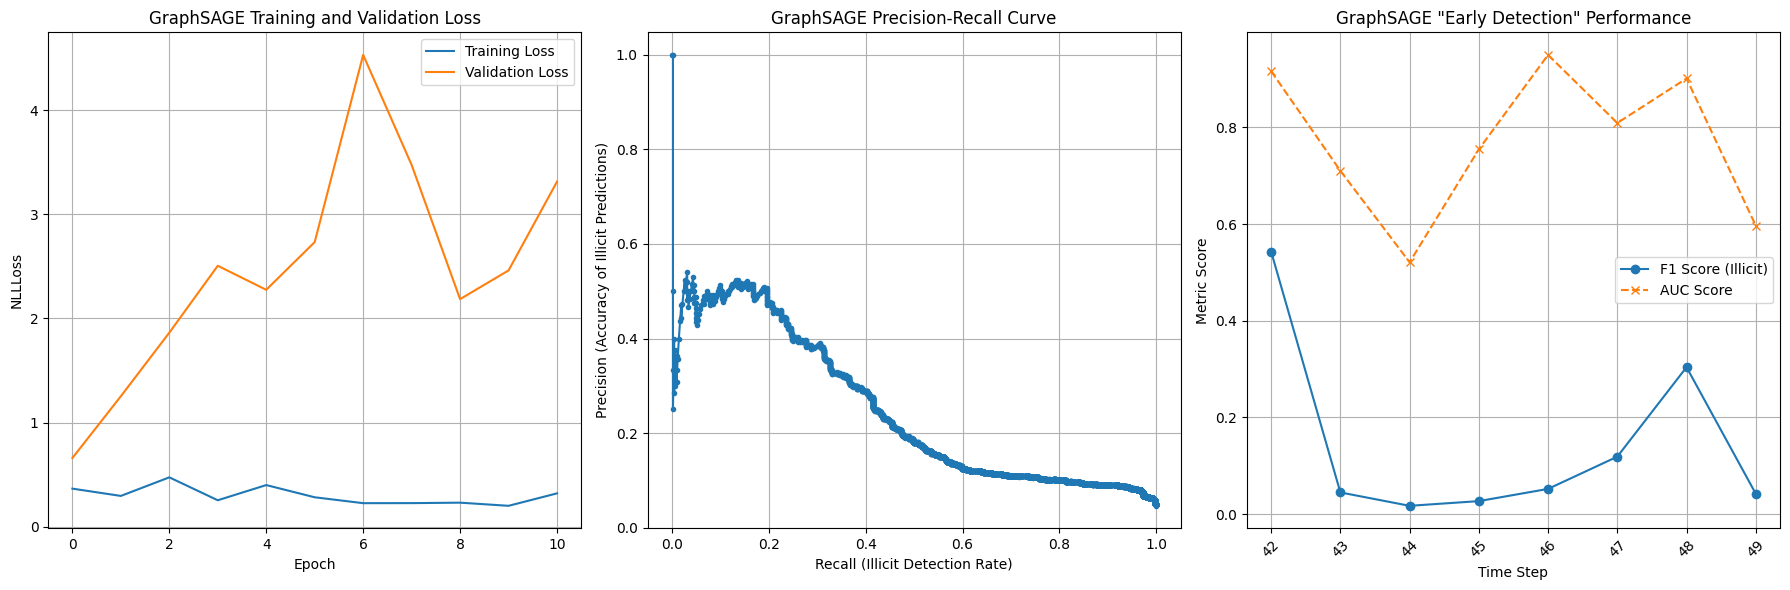

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from torch_geometric.loader import NeighborLoader
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, roc_auc_score, f1_score, 
    precision_score, recall_score, precision_recall_curve, log_loss
)
import matplotlib.pyplot as plt

# --- Step 1: Load and Prepare Full Graph Data ---
print("Starting Step 1: Load and Prepare Full Graph Data...")
try:
    df_features = pd.read_csv('/kaggle/input/elliptic/elliptic/elliptic_txs_features.csv', header=None)
    df_classes = pd.read_csv('/kaggle/input/elliptic/elliptic/elliptic_txs_classes.csv')
    df_edgelist = pd.read_csv('/kaggle/input/elliptic/elliptic/elliptic_txs_edgelist.csv')
except FileNotFoundError:
    print("Error: CSV files not found. Please download the Elliptic dataset.")
    exit()

feature_cols = ['txId', 'timestep'] + [f'local_{i}' for i in range(93)] + [f'agg_{i}' for i in range(72)]
df_features.columns = feature_cols

all_tx_ids = df_features['txId'].unique()
tx_id_map = {tx_id: i for i, tx_id in enumerate(all_tx_ids)}

df_edgelist['txId1_idx'] = df_edgelist['txId1'].map(tx_id_map)
df_edgelist['txId2_idx'] = df_edgelist['txId2'].map(tx_id_map)

df_merged = pd.merge(df_features, df_classes, on='txId', how='left')
df_merged['class'] = df_merged['class'].map({'2': 0, '1': 1, 'unknown': np.nan})
df_merged = df_merged.set_index('txId').loc[all_tx_ids].reset_index()

print(f"Data loaded. Total nodes: {len(df_merged)}")

# --- Step 2: Feature Scaling & Create Masks ---
print("\nStarting Step 2: Feature Scaling and Mask Creation...")
features = [col for col in df_features.columns if col not in ['txId']]
X_df = df_merged[features]
y_series = df_merged['class']

train_mask_idx = X_df.index[
    (X_df['timestep'] >= 1) & (X_df['timestep'] <= 34) & (y_series.notna())
].values
val_mask_idx = X_df.index[
    (X_df['timestep'] >= 35) & (X_df['timestep'] <= 41) & (y_series.notna())
].values
test_mask_idx = X_df.index[
    (X_df['timestep'] >= 42) & (X_df['timestep'] <= 49) & (y_series.notna())
].values

scaler = StandardScaler()
X_train_features = X_df.loc[train_mask_idx, features]
scaler.fit(X_train_features)
X_scaled = scaler.transform(X_df)

print(f"Train nodes: {len(train_mask_idx)}, Val nodes: {len(val_mask_idx)}, Test nodes: {len(test_mask_idx)}")

# --- Step 3: Create PyTorch Geometric Data Object ---
print("\nStarting Step 3: Create PyG Data Object...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create the Data object on CPU
data = Data(
    x=torch.tensor(X_scaled, dtype=torch.float),
    edge_index=torch.tensor(df_edgelist[['txId1_idx', 'txId2_idx']].values.T, dtype=torch.long),
    y=torch.tensor(y_series.values, dtype=torch.long),
    timestep=torch.tensor(X_df['timestep'].values, dtype=torch.long)
)

# Store indices, not boolean masks, for NeighborLoader
data.train_mask = torch.tensor(train_mask_idx, dtype=torch.long)
data.val_mask = torch.tensor(val_mask_idx, dtype=torch.long)
data.test_mask = torch.tensor(test_mask_idx, dtype=torch.long)

# --- Calculate Class Weights ---
y_train_only = data.y[data.train_mask].cpu().numpy()
weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_only), y=y_train_only)
class_weights = torch.tensor(weights, dtype=torch.float).to(device)
print(f"Calculated class weights: {class_weights}")

# --- Step 4: Create Inductive DataLoaders (NeighborLoader) ---
print("\nStarting Step 4: Create Inductive DataLoaders...")
train_loader = NeighborLoader(
    data,
    num_neighbors=[10, 10], 
    batch_size=512,
    input_nodes=data.train_mask,
    shuffle=True
)

val_loader = NeighborLoader(
    data,
    num_neighbors=[10, 10],
    batch_size=512,
    input_nodes=data.val_mask
)

test_loader = NeighborLoader(
    data,
    num_neighbors=[10, 10],
    batch_size=512,
    input_nodes=data.test_mask
)

# --- Step 5: Define GraphSAGE Model ---
print("\nStarting Step 5: Define GraphSAGE Model...")

class GraphSAGE(torch.nn.Module):
    def __init__(self, num_features, hidden_dim, num_classes):
        super(GraphSAGE, self).__init__()
        self.conv1 = SAGEConv(num_features, hidden_dim, aggr='mean')
        self.conv2 = SAGEConv(hidden_dim, num_classes, aggr='mean')
        self.dropout = torch.nn.Dropout(p=0.5)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

model = GraphSAGE(
    num_features=data.num_features,
    hidden_dim=128,
    num_classes=2
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = torch.nn.NLLLoss(weight=class_weights)

# --- Step 6: Training and Validation Loop (Inductive) ---
print("\nStarting Step 6: Training GraphSAGE Model...")

train_losses = []
val_losses = []
num_epoch = 100
best_val_loss = float('inf')
patience = 10
patience_counter = 0

for epoch in range(num_epoch): 
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        out = model(batch.x, batch.edge_index)
        loss = loss_fn(out[:batch.batch_size], batch.y[:batch.batch_size])
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index)
            loss = loss_fn(out[:batch.batch_size], batch.y[:batch.batch_size])
            total_val_loss += loss.item()
    
    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:03d}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_sage_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}!")
            break

print("Training complete. Loading best model...")
model.load_state_dict(torch.load('best_sage_model.pth'))

# --- Step 7: Final Evaluation (Overall) ---
print("\nStarting Step 7: Final Evaluation (Overall)...")
model.eval()

all_y_true = []
all_y_pred = []
all_y_proba = []
all_timesteps = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index)
        
        target_out = out[:batch.batch_size]
        target_y = batch.y[:batch.batch_size]
        
        target_n_ids = batch.n_id[:batch.batch_size]
        
        # --- SỬA LỖI Ở ĐÂY ---
        # Chuyển 'target_n_ids' (trên GPU) về CPU trước khi lập chỉ mục 'data.timestep' (trên CPU)
        target_timesteps = data.timestep[target_n_ids.cpu()].numpy()
        # --- KẾT THÚC SỬA LỖI ---

        all_y_true.append(target_y.cpu().numpy())
        all_y_pred.append(target_out.argmax(dim=1).cpu().numpy())
        all_y_proba.append(target_out.exp()[:, 1].cpu().numpy())
        all_timesteps.append(target_timesteps)

y_true = np.concatenate(all_y_true)
y_pred = np.concatenate(all_y_pred)
y_proba = np.concatenate(all_y_proba)
timesteps = np.concatenate(all_timesteps)

# Calculate metrics
precision_illicit = precision_score(y_true, y_pred, pos_label=1)
recall_illicit = recall_score(y_true, y_pred, pos_label=1)
f1_illicit = f1_score(y_true, y_pred, pos_label=1)
auc_score = roc_auc_score(y_true, y_proba)

print("--- PERFORMANCE REPORT (BASELINE: GraphSAGE) ---")
print(f"\nMetrics for 'Illicit' (Class 1):")
print(f"  Precision: {precision_illicit:.4f}")
print(f"  Recall:    {recall_illicit:.4f}")
print(f"  F1-Score:  {f1_illicit:.4f}")
print(f"\nOverall Metrics:")
print(f"  ROC AUC:   {auc_score:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Licit (0)', 'Illicit (1)']))

# --- Step 8: Temporal "Early Detection" Evaluation ---
print("\nStarting Step 8: Temporal 'Early Detection' Evaluation...")

test_timesteps_unique = sorted(np.unique(timesteps))
f1_over_time = []
auc_over_time = []

for t in test_timesteps_unique:
    t_mask = (timesteps == t)
    
    t_y_true = y_true[t_mask]
    t_y_pred = y_pred[t_mask]
    t_y_proba = y_proba[t_mask]
    
    if len(t_y_true) > 0:
        t_f1 = f1_score(t_y_true, t_y_pred, pos_label=1, zero_division=0)
        f1_over_time.append(t_f1)
        
        try:
            t_auc = roc_auc_score(t_y_true, t_y_proba)
            auc_over_time.append(t_auc)
        except ValueError:
            auc_over_time.append(np.nan)

print(f"Test Timesteps: {test_timesteps_unique}")
print(f"F1 over time:   {[round(f, 3) for f in f1_over_time]}")
print(f"AUC over time:  {[round(a, 3) if not np.isnan(a) else 'N/A' for a in auc_over_time]}")

# --- Step 9: Plotting ---
print("\nStarting Step 9: Plotting...")

plt.figure(figsize=(18, 6))

# 1. Plot Loss Curve
plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('GraphSAGE Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('NLLLoss')
plt.legend()
plt.grid(True)

# 2. Plot Precision-Recall Curve
plt.subplot(1, 3, 2)
precision, recall, _ = precision_recall_curve(y_true, y_proba, pos_label=1)
plt.plot(recall, precision, marker='.')
plt.title('GraphSAGE Precision-Recall Curve')
plt.xlabel('Recall (Illicit Detection Rate)')
plt.ylabel('Precision (Accuracy of Illicit Predictions)')
plt.grid(True)

# 3. Plot F1 Score over Time
plt.subplot(1, 3, 3)
plt.plot(test_timesteps_unique, f1_over_time, marker='o', label='F1 Score (Illicit)')
plt.plot(test_timesteps_unique, auc_over_time, marker='x', label='AUC Score', linestyle='--')
plt.title('GraphSAGE "Early Detection" Performance')
plt.xlabel('Time Step')
plt.ylabel('Metric Score')
plt.xticks(test_timesteps_unique, rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('graphsage_baseline_results.png')
print("All plots saved to 'graphsage_baseline_results.png'")